In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor

In [29]:
train_path = "train.csv"
test_path = "test.csv"

train = pd.read_csv("/kaggle/input/datasets/harshilgoel2007/trafficdemad/train.csv")
test = pd.read_csv("/kaggle/input/datasets/harshilgoel2007/trafficdemad/test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
train.head()

Train Shape: (77299, 11)
Test Shape: (41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [30]:
print(train.info())
print("\nMissing Values\n", train.isnull().sum())
print("\nUnique Values\n", train.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB
None

Missing Values
 Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather        

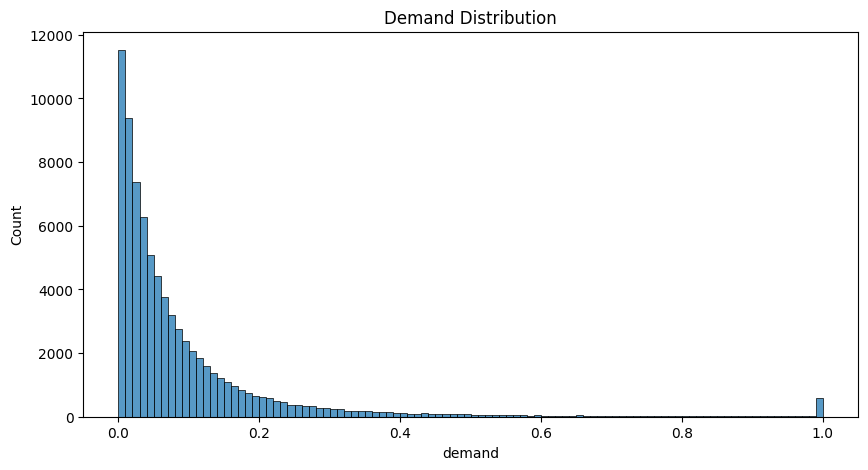

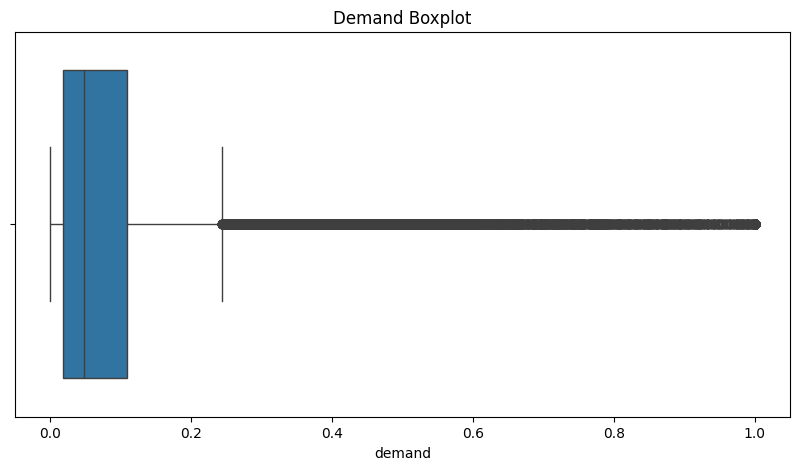

Skewness: 3.7285172887316627


In [31]:
plt.figure(figsize=(10,5))
sns.histplot(train["demand"], bins=100)
plt.title("Demand Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=train["demand"])
plt.title("Demand Boxplot")
plt.show()

print("Skewness:", train["demand"].skew())

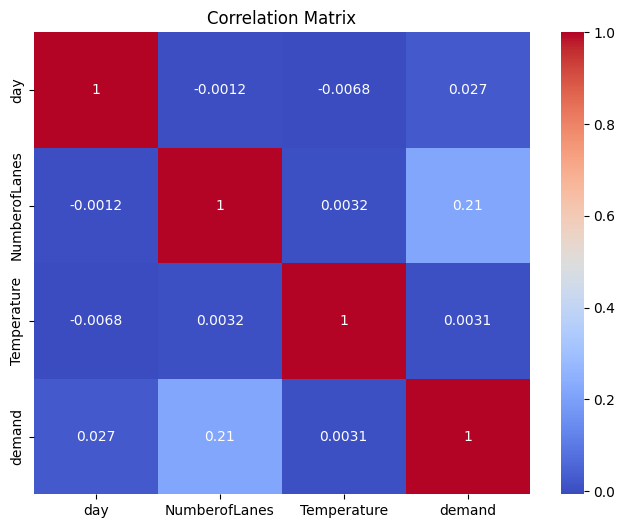

In [32]:
num_cols = ["day","NumberofLanes","Temperature","demand"]
corr = train[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

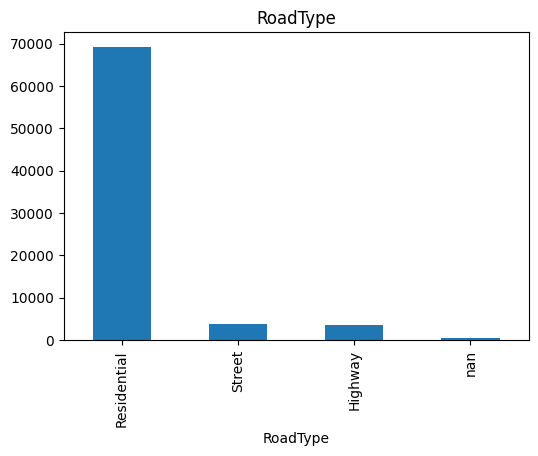

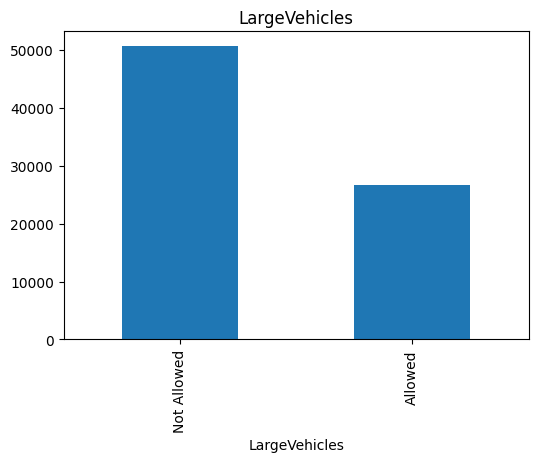

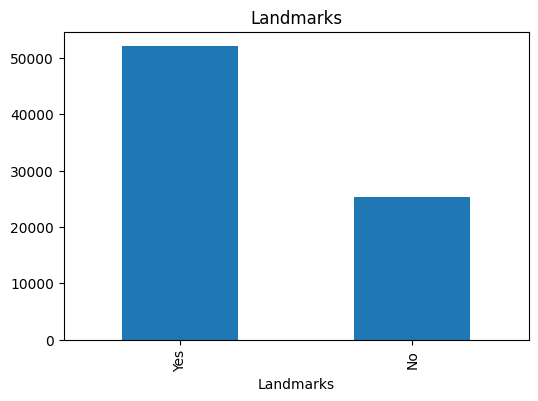

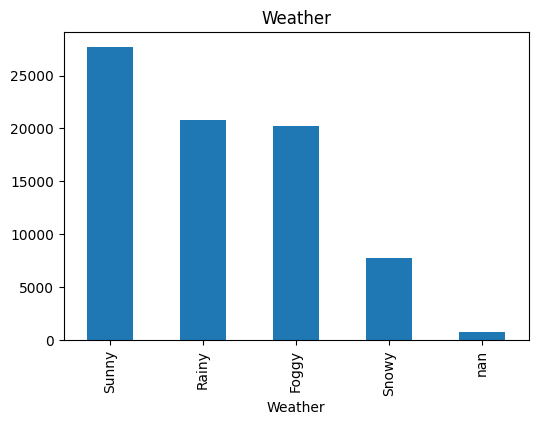

In [33]:
cat_cols = ["RoadType","LargeVehicles","Landmarks","Weather"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    train[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(col)
    plt.show()

In [54]:
def create_features(df):

    df = df.copy()

    df["hour"] = df["timestamp"].str.split(":").str[0].astype(int)
    df["minute"] = df["timestamp"].str.split(":").str[1].astype(int)

    df["time_in_minutes"] = df["hour"] * 60 + df["minute"]

    df["is_morning_peak"] = df["hour"].between(7,10).astype(int)
    df["is_evening_peak"] = df["hour"].between(16,20).astype(int)

    df["is_weekend_like"] = (df["day"] == 49).astype(int)

    df = df.drop(columns=['timestamp'])

    return df

In [55]:
train = create_features(train)
test = create_features(test)

for df in [train, test]:
    df["Temperature"] = df["Temperature"].fillna(df["Temperature"].median())
    df["RoadType"] = df["RoadType"].fillna(df["RoadType"].mode()[0])
    df["Weather"] = df["Weather"].fillna(df["Weather"].mode()[0])

In [56]:
X = train.drop(columns=["demand"])
y = train["demand"]

X_test = test.copy()

X = X.drop(columns=["Index"])
X_test = X_test.drop(columns=["Index"])

y_log = np.log1p(y)

cat_features = [
    X.columns.get_loc("geohash"),
    X.columns.get_loc("RoadType"),
    X.columns.get_loc("LargeVehicles"),
    X.columns.get_loc("Landmarks"),
    X.columns.get_loc("Weather")
]

In [40]:
X

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,time_in_minutes,is_morning_peak,is_evening_peak,is_weekend_like
0,qp02z1,48,Residential,1,Not Allowed,No,16.382587,Sunny,0,0,0,0,0,0
1,qp02zt,48,Residential,3,Allowed,Yes,31.104565,Sunny,0,0,0,0,0,0
2,qp08bj,48,Residential,1,Not Allowed,No,25.919267,Sunny,0,0,0,0,0,0
3,qp08gt,48,Residential,1,Not Allowed,No,16.382587,Rainy,0,0,0,0,0,0
4,qp02zq,48,Residential,1,Not Allowed,No,10.803667,Rainy,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,49,Residential,1,Not Allowed,No,11.501664,Rainy,2,0,120,0,0,1
77295,qp0d4q,49,Residential,3,Allowed,Yes,14.715254,Foggy,2,0,120,0,0,1
77296,qp0d4w,49,Residential,3,Allowed,Yes,19.678860,Sunny,2,0,120,0,0,1
77297,qp0dhw,49,Residential,1,Not Allowed,No,22.573958,Sunny,2,0,120,0,0,1


In [62]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

model = CatBoostRegressor(
    iterations=8000,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="R2",
    random_seed=42,
    verbose=250
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

pred_log = model.predict(X_valid)

pred = np.expm1(pred_log)
actual = np.expm1(y_valid)

print("Validation R2 =", r2_score(actual, pred))

0:	learn: 0.0436331	test: 0.0441438	best: 0.0441438 (0)	total: 23.6ms	remaining: 3m 9s
250:	learn: 0.9086662	test: 0.9131864	best: 0.9131864 (250)	total: 7.06s	remaining: 3m 37s
500:	learn: 0.9230642	test: 0.9248130	best: 0.9248130 (500)	total: 15.1s	remaining: 3m 46s
750:	learn: 0.9301676	test: 0.9301453	best: 0.9301453 (750)	total: 23.3s	remaining: 3m 44s
1000:	learn: 0.9353231	test: 0.9337704	best: 0.9337710 (999)	total: 31.1s	remaining: 3m 37s
1250:	learn: 0.9390361	test: 0.9358963	best: 0.9358963 (1250)	total: 39.2s	remaining: 3m 31s
1500:	learn: 0.9417613	test: 0.9371808	best: 0.9371808 (1500)	total: 46.9s	remaining: 3m 23s
1750:	learn: 0.9441080	test: 0.9383165	best: 0.9383165 (1750)	total: 55s	remaining: 3m 16s
2000:	learn: 0.9461515	test: 0.9392584	best: 0.9392584 (2000)	total: 1m 3s	remaining: 3m 10s
2250:	learn: 0.9478918	test: 0.9399422	best: 0.9399422 (2250)	total: 1m 12s	remaining: 3m 4s
2500:	learn: 0.9493744	test: 0.9403893	best: 0.9403893 (2500)	total: 1m 20s	remaining

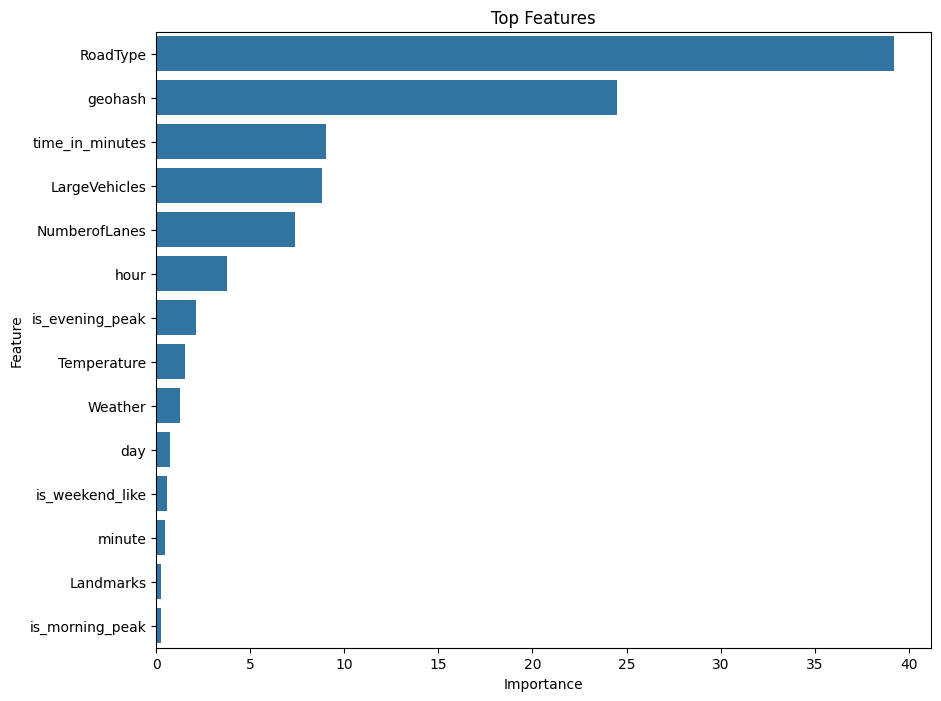

,Feature,Importance
2,RoadType,39.229979
0,geohash,24.491330
10,time_in_minutes,9.046131
4,LargeVehicles,8.821254
3,NumberofLanes,7.403307
8,hour,3.740880
12,is_evening_peak,2.136337
6,Temperature,1.553227
7,Weather,1.253270
1,day,0.727955


In [67]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(15), x="Importance", y="Feature")
plt.title("Top Features")
plt.show()

importance.head(20)

In [57]:
X_test

,geohash,day,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,time_in_minutes,is_morning_peak,is_evening_peak,is_weekend_like
0,qp02z1,49,Residential,1,Not Allowed,No,16.471232,Sunny,2,15,135,0,0,1
1,qp02z9,49,Residential,1,Not Allowed,No,6.476213,Snowy,2,15,135,0,0,1
2,qp02yf,49,Residential,3,Allowed,Yes,22.318203,Sunny,2,15,135,0,0,1
3,qp02z6,49,Residential,2,Not Allowed,Yes,16.471232,Rainy,2,15,135,0,0,1
4,qp02zd,49,Residential,1,Not Allowed,No,18.266162,Foggy,2,15,135,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,49,Street,1,Not Allowed,Yes,19.588991,Sunny,13,45,825,0,0,1
41774,qp0d4w,49,Residential,2,Not Allowed,Yes,10.735538,Rainy,13,45,825,0,0,1
41775,qp0dhq,49,Residential,2,Not Allowed,Yes,13.223750,Rainy,13,45,825,0,0,1
41776,qp0dhw,49,Residential,2,Not Allowed,Yes,12.510917,Rainy,13,45,825,0,0,1


In [68]:
test_preds_log = model.predict(X_test)
test_preds = np.expm1(test_preds_log)
test_preds = np.clip(test_preds, 0, 1)

submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": test_preds
})

submission.to_csv("sample_submission.csv", index=False)

print("sample_submission.csv saved")
print(submission.shape)
submission.head()

sample_submission.csv saved
(41778, 2)


,Index,demand
0,0,0.061990
1,1,0.025343
2,2,0.005368
3,3,0.025609
4,4,0.063825
